##ANÁLISIS DE TRANSACCIÓNES MUNICIPALES

**Problema:** como se reparten los recursos que el Estado transfiere a las municipalidades
del pais, y que municipalidades quedan en los extremos de ese reparto.

| | |
|---|---|
| **Fuente A (principal)** | MEF — Transferencias de fondos y asignaciones financieras, 2024 |
| **Fuente B** | INEI — Registro Nacional de Municipalidades (RENAMU) 2025 |
| **Clave de integracion** | UBIGEO de 6 digitos |
| **Unidad de analisis** | una municipalidad (un distrito) en el ejercicio 2024 |

Flujo: carga -> inspeccion -> tabla resumen -> validacion de clave -> duplicados ->
limpieza -> integracion -> auditoria del cruce -> visualizaciones -> conclusiones.

> Ejecutar en Google Colab: `Entorno de ejecucion` > `Ejecutar todas`.

## 0. Configuracion e importaciones

Solo pandas, numpy y matplotlib bastarán para el hito 1.

In [4]:
import os, zipfile, glob, time, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
AZUL, ORO, GRIS = "#1F3864", "#BF8F00", "#9AA0A6"

#Guarde automático cada gráfico para ponerlo en el informe sin tener que capturar la pantalla.
#Se numeran en el orden en que se generan. Si se reejecuta una celda suelta, la numeracion se corre.
os.makedirs("graficos", exist_ok=True)
_n_grafico = [0]
_show = plt.show

def _guardar_y_mostrar(*a, **k):
    _n_grafico[0] += 1
    ruta = f"graficos/grafico_{_n_grafico[0]:02d}.png"
    plt.gcf().savefig(ruta, dpi=150, bbox_inches="tight")
    print(f"[guardado: {ruta}]")
    _show(*a, **k)

plt.show = _guardar_y_mostrar

#Ejercicio a analizar. Si el archivo de un ano resultara demasiado pesado,
# se puede bajar a un ano anterior sin cambiar nada mas del cuaderno.
ANIO = 2024

#True guarda las descargas en Google Drive: sobreviven a una desconexion
#del entorno de Colab y no hay que volver a bajarlas.
GUARDAR_EN_DRIVE = False

CARPETA = "datos"
if GUARDAR_EN_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        CARPETA = "/content/drive/MyDrive/hito1_datos"
    except Exception as e:
        print("No se pudo montar Drive, se usara almacenamiento temporal:", e)

os.makedirs(CARPETA, exist_ok=True)
print(f"Ejercicio: {ANIO}  |  Carpeta de datos: {CARPETA}  |  pandas {pd.__version__}")

Ejercicio: 2024  |  Carpeta de datos: datos  |  pandas 2.2.3


## 1. Descarga de las fuentes

Ambas son de descarga directa, sin usuario ni contrasena.

| Fuente | Entidad | Archivo | Enlace |
|---|---|---|---|
| A | MEF | `2024-Transferencias.csv` | `https://fs.datosabiertos.mef.gob.pe/datastorefiles/2024-Transferencias.csv` |
| A (diccionario) | MEF | `Transferencias_Diccionario.csv` | `https://fs.datosabiertos.mef.gob.pe/datastorefiles/Transferencias_Diccionario.csv` |
| B | INEI | `984-Modulo1963.zip` | `https://proyectos.inei.gob.pe/iinei/srienaho/descarga/CSV/984-Modulo1963.zip` |

**Ruta de obtencion manual**, por si el enlace directo cambiara:

- MEF: Plataforma Nacional de Datos Abiertos > buscar *"Transferencias de fondos y
  asignaciones financieras"* > organizacion *Ministerio de Economia y Finanzas* >
  recurso `2024-Transferencias.csv` > Descargar.
- INEI: Plataforma Nacional de Datos Abiertos > buscar *"RENAMU 2025"* > recurso
  *"Data completa del Registro Nacional de Municipalidades (RENAMU) 2025"* > Descargar.

La celda consulta primero **cuanto pesa cada archivo** y luego descarga mostrando progreso.
Si un archivo ya esta completo en la carpeta, no lo vuelve a bajar.

In [5]:
BASE_MEF     = "https://fs.datosabiertos.mef.gob.pe/datastorefiles/"
URL_MEF      = f"{BASE_MEF}{ANIO}-Transferencias.csv"
URL_MEF_DIC  = f"{BASE_MEF}Transferencias_Diccionario.csv"
URL_RENAMU   = "https://proyectos.inei.gob.pe/iinei/srienaho/descarga/CSV/984-Modulo1963.zip"

RUTA_MEF     = f"{CARPETA}/{ANIO}-Transferencias.csv"
RUTA_MEF_DIC = f"{CARPETA}/Transferencias_Diccionario.csv"
RUTA_RENAMU  = f"{CARPETA}/renamu2025.zip"


def sondear(url):
    """Consulta el tamano del archivo sin descargarlo."""
    try:
        r = requests.head(url, timeout=30, allow_redirects=True, verify=False)
        n = int(r.headers.get("content-length", 0))
        return n, (f"{n/1024**2:,.0f} MB" if n else "tamano no informado")
    except Exception as e:
        return 0, f"no se pudo consultar ({e})"


def descargar(url, destino, avisar_cada_mb=10):
    """Descarga mostrando progreso. Si ya existe el archivo, no lo repite."""
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        print(f"Ya existe: {os.path.basename(destino)}  "
              f"({os.path.getsize(destino)/1024**2:,.1f} MB)")
        return

    with requests.get(url, stream=True, timeout=(30, 180), verify=False) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        print(f"Descargando {os.path.basename(destino)} — "
              + (f"{total/1024**2:,.0f} MB" if total else "tamano desconocido"))

        bajado, ultimo, t0 = 0, 0, time.time()
        with open(destino, "wb") as f:
            for trozo in r.iter_content(chunk_size=1024 * 1024):
                if not trozo:
                    continue
                f.write(trozo)
                bajado += len(trozo)
                if bajado - ultimo >= avisar_cada_mb * 1024**2:
                    ultimo = bajado
                    seg = time.time() - t0
                    vel = bajado / 1024**2 / max(seg, 1)
                    pct = f"{100*bajado/total:5.1f}%  " if total else ""
                    print(f"   {pct}{bajado/1024**2:7,.0f} MB   {vel:5.1f} MB/s   {seg:5.0f} s")

    print(f"Listo: {os.path.basename(destino)}  "
          f"({os.path.getsize(destino)/1024**2:,.1f} MB)\n")


print("Tamanos antes de descargar:")
bytes_mef = 0
for nombre, url in [("diccionario MEF", URL_MEF_DIC),
                    ("RENAMU (zip)",    URL_RENAMU),
                    (f"transferencias {ANIO}", URL_MEF)]:
    n, txt = sondear(url)
    if "transferencias" in nombre:
        bytes_mef = n
    print(f"  {nombre:<22} {txt}")

if bytes_mef > 1.5 * 1024**3:
    print("\nAVISO: el archivo del MEF supera 1.5 GB. Conviene bajar el valor de ANIO "
          "a un ejercicio anterior antes de continuar.")
print()

descargar(URL_MEF_DIC, RUTA_MEF_DIC)
descargar(URL_RENAMU,  RUTA_RENAMU)
descargar(URL_MEF,     RUTA_MEF)

Tamanos antes de descargar:
  diccionario MEF        0 MB
  RENAMU (zip)           2 MB
  transferencias 2024    107 MB

Descargando Transferencias_Diccionario.csv — 0 MB
Listo: Transferencias_Diccionario.csv  (0.0 MB)

Descargando renamu2025.zip — 2 MB
Listo: renamu2025.zip  (2.1 MB)

Descargando 2024-Transferencias.csv — 107 MB
     9.3%       10 MB     6.3 MB/s       2 s
    18.7%       20 MB     9.6 MB/s       2 s
    28.0%       30 MB    11.6 MB/s       3 s
    37.4%       40 MB    13.0 MB/s       3 s
    46.7%       50 MB    13.4 MB/s       4 s
    56.1%       60 MB    14.2 MB/s       4 s
    65.4%       70 MB    15.0 MB/s       5 s
    74.8%       80 MB    15.5 MB/s       5 s
    84.1%       90 MB    15.9 MB/s       6 s
    93.5%      100 MB    16.4 MB/s       6 s
Listo: 2024-Transferencias.csv  (107.0 MB)



## 2. Utilidades de lectura

No suponemos el separador ni la codificacion: los detectamos. Los CSV de entidades
publicas peruanas suelen venir en `latin-1` y a veces separados por `;`, de modo que
probar en lugar de asumir evita el error mas frecuente de esta etapa.

In [6]:
def detectar_formato(ruta, nfilas=5):
    """Prueba combinaciones de separador y codificacion y devuelve la que funciona."""
    for enc in ["utf-8", "latin-1", "cp1252"]:
        for sep in [",", ";", "|", "\t"]:
            try:
                m = pd.read_csv(ruta, sep=sep, encoding=enc, nrows=nfilas,
                                dtype=str, engine="python")
                if m.shape[1] > 1:
                    return sep, enc, m
            except Exception:
                continue
    raise ValueError(f"No se pudo leer {ruta}")

SEP_MEF, ENC_MEF, muestra_mef = detectar_formato(RUTA_MEF)
print(f"Fuente A -> separador '{SEP_MEF}' | codificacion '{ENC_MEF}' | "
      f"{muestra_mef.shape[1]} columnas")
muestra_mef.head(3)

Fuente A -> separador ',' | codificacion 'utf-8' | 26 columnas


,ANO_PRC,MES_PRC,MES_PRC_NOMBRE,GRUPO_TRANSFERENCIA,GRUPO_TRANSFERENCIA_NOMBRE,TIPO_ENTIDAD,TIPO_ENTIDAD_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA_NOMBRE,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,RUBRO,RUBRO_NOMBRE,FUENTE,FUENTE_NOMBRE,RECURSO,RECURSO_NOMBRE,ORIGEN_OPERACION_NOMBRE,MONTO_AUTORIZADO,MONTO_ACREDITADO
0,2024,6,JUNIO,4,INTERESES,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,08,IMPUESTOS MUNICIPALES,5,RECURSOS DETERMINADOS,729,IMPUESTOS MUNICIPALES,INTERESES DE ASIGNACION,313.3,313.3
1,2024,4,ABRIL,1,RECURSOS AUTORIZADOS,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,09,RECURSOS DIRECTAMENTE RECAUDADOS,2,RECURSOS DIRECTAMENTE RECAUDADOS,516,RECURSOS DIRECTAMENTE RECAUDADOS,ASIGNACION NORMAL,100000,100000
2,2024,2,FEBRERO,4,INTERESES,M,GOBIERNO LOCAL,,,301086,MUNICIPALIDAD PROVINCIAL DE JUNIN,12,JUNIN,05,JUNIN,01,JUNIN,07,FONDO DE COMPENSACION MUNICIPAL,5,RECURSOS DETERMINADOS,547,SUB CUENTA - SALDOS DE TRANSFERENCIAS - FONCOMUN,INTERESES DE ASIGNACION,0.22,0.22


## 3. Inspeccion inicial de la Fuente A (MEF — Transferencias)

Miramos el diccionario oficial, las columnas reales del archivo y las categorias
de las variables que vamos a usar para filtrar. Todo antes de cargar nada pesado.

In [7]:
sep_d, enc_d, _ = detectar_formato(RUTA_MEF_DIC)
diccionario_mef = pd.read_csv(RUTA_MEF_DIC, sep=sep_d, encoding=enc_d, dtype=str)
print("Diccionario oficial del MEF:", diccionario_mef.shape)
diccionario_mef

Diccionario oficial del MEF: (26, 3)


,COLUMNA,TIPO_DATO,DESCRIPCION
0,ANO_PRC,Numérico,Año del proceso de la operación
1,MES_PRC,Numérico,Mes del proceso de la operación
2,MES_PRC_NOMBRE,Carácter,Nombre del mes del proceso de la operación
3,GRUPO_TRANSFERENCIA,Numérico,Código del grupo de Transferencia
4,GRUPO_TRANSFERENCIA_NOMBRE,Carácter,Nombre del grupo de Transferencia
5,TIPO_ENTIDAD,Carácter,Código de la Entidad SIAF
6,TIPO_ENTIDAD_NOMBRE,Carácter,Nombre de la Entidad SIAF
7,PLIEGO,Numérico,Código del Pliego
8,PLIEGO_NOMBRE,Carácter,Nombre del Pliego
9,SEC_EJEC,Numérico,Código de la Unidad Ejecutora


In [8]:
columnas_mef = list(muestra_mef.columns)
print(f"El archivo trae {len(columnas_mef)} columnas:\n")
for i, col in enumerate(columnas_mef, 1):
    print(f"{i:>2}. {col}")

El archivo trae 26 columnas:

 1. ANO_PRC
 2. MES_PRC
 3. MES_PRC_NOMBRE
 4. GRUPO_TRANSFERENCIA
 5. GRUPO_TRANSFERENCIA_NOMBRE
 6. TIPO_ENTIDAD
 7. TIPO_ENTIDAD_NOMBRE
 8. PLIEGO
 9. PLIEGO_NOMBRE
10. SEC_EJEC
11. EJECUTORA_NOMBRE
12. DEPARTAMENTO_EJECUTORA
13. DEPARTAMENTO_EJECUTORA_NOMBRE
14. PROVINCIA_EJECUTORA
15. PROVINCIA_EJECUTORA_NOMBRE
16. DISTRITO_EJECUTORA
17. DISTRITO_EJECUTORA_NOMBRE
18. RUBRO
19. RUBRO_NOMBRE
20. FUENTE
21. FUENTE_NOMBRE
22. RECURSO
23. RECURSO_NOMBRE
24. ORIGEN_OPERACION_NOMBRE
25. MONTO_AUTORIZADO
26. MONTO_ACREDITADO


In [9]:
#Columnas que el problema necesita. Si alguna faltara, el codigo lo avisa.
DESEADAS = [
    "ANO_PRC", "MES_PRC",
    "TIPO_ENTIDAD", "TIPO_ENTIDAD_NOMBRE",
    "PLIEGO_NOMBRE", "SEC_EJEC", "EJECUTORA_NOMBRE",
    "DEPARTAMENTO_EJECUTORA", "DEPARTAMENTO_EJECUTORA_NOMBRE",
    "PROVINCIA_EJECUTORA",    "PROVINCIA_EJECUTORA_NOMBRE",
    "DISTRITO_EJECUTORA",     "DISTRITO_EJECUTORA_NOMBRE",
    "RUBRO_NOMBRE", "FUENTE_NOMBRE", "RECURSO_NOMBRE",
    "MONTO_AUTORIZADO", "MONTO_ACREDITADO",
]

USAR   = [x for x in DESEADAS if x in columnas_mef]
FALTAN = [x for x in DESEADAS if x not in columnas_mef]

print("Se usaran", len(USAR), "columnas")
if FALTAN:
    print("ATENCION - no estan en el archivo:", FALTAN)

IMPRESCINDIBLES = ["DEPARTAMENTO_EJECUTORA", "PROVINCIA_EJECUTORA",
                   "DISTRITO_EJECUTORA", "MONTO_ACREDITADO"]
assert all(x in USAR for x in IMPRESCINDIBLES), \
    f"Faltan columnas imprescindibles: {[x for x in IMPRESCINDIBLES if x not in USAR]}"
print("Verificacion de columnas imprescindibles: OK")

Se usaran 18 columnas
Verificacion de columnas imprescindibles: OK


### 3.1 Que categorias trae la variable con la que vamos a filtrar

El archivo incluye transferencias a los tres niveles de gobierno. Necesitamos quedarnos
solo con los **gobiernos locales**, asi que primero vemos que valores existen realmente
en `TIPO_ENTIDAD_NOMBRE`, en lugar de asumirlos.

In [10]:
sonda = pd.read_csv(RUTA_MEF, sep=SEP_MEF, encoding=ENC_MEF,
                    usecols=USAR, dtype=str, nrows=300_000)

print("Categorias de TIPO_ENTIDAD_NOMBRE en las primeras 300 000 filas:\n")
print(sonda["TIPO_ENTIDAD_NOMBRE"].value_counts(dropna=False))

print("\nPrincipales rubros de transferencia:\n")
print(sonda["RUBRO_NOMBRE"].value_counts(dropna=False).head(10))

Categorias de TIPO_ENTIDAD_NOMBRE en las primeras 300 000 filas:

TIPO_ENTIDAD_NOMBRE
GOBIERNO LOCAL    299984
MANCOMUNIDADES        16
Name: count, dtype: int64

Principales rubros de transferencia:

RUBRO_NOMBRE
CANON Y SOBRECANON, REGALIAS, RENTA DE ADUANAS Y PARTICIPACIONES    155870
FONDO DE COMPENSACION MUNICIPAL                                      51470
RECURSOS DIRECTAMENTE RECAUDADOS                                     35073
IMPUESTOS MUNICIPALES                                                31571
RECURSOS ORDINARIOS                                                  25698
DONACIONES Y TRANSFERENCIAS                                            190
RECURSOS POR OPERACIONES OFICIALES DE CREDITO                          128
Name: count, dtype: int64


In [11]:
# Nos quedamos con las entidades cuyo tipo menciona 'LOCAL'.
# Se comprueba contra los valores reales antes de aplicarlo a todo el archivo.
etiquetas = sonda["TIPO_ENTIDAD_NOMBRE"].dropna().unique()
LOCALES = [e for e in etiquetas if "LOCAL" in str(e).upper()]

print("Etiquetas que se consideraran gobiernos locales:", LOCALES)
assert LOCALES, ("Ninguna categoria contiene 'LOCAL'. Revisar los valores impresos arriba "
                 "y ajustar el filtro a mano.")

Etiquetas que se consideraran gobiernos locales: ['GOBIERNO LOCAL']


### 3.2 Lectura por bloques y agregacion

El archivo esta al nivel de *unidad ejecutora x mes x rubro x concepto*.
Nuestra unidad de analisis es el **distrito**, asi que leemos por bloques, filtramos
gobiernos locales y vamos sumando por UBIGEO.

Dos decisiones tecnicas que importan:

1. Los codigos geograficos se leen como **texto** (`dtype=str`). Si se leyeran como numero,
   Amazonas (`01`) pasaria a `1` y se romperia el cruce.
2. Los montos se convierten con `errors="coerce"`: un valor corrupto se vuelve nulo y lo
   contamos, en vez de detener la ejecucion.

In [12]:
MONTOS = [m for m in ["MONTO_AUTORIZADO", "MONTO_ACREDITADO"] if m in USAR]

tipos = {col: str for col in USAR}
for m in MONTOS:
    tipos.pop(m, None)

acumulado, catalogo, por_rubro = [], [], []
filas_total = filas_local = 0
montos_nulos = {m: 0 for m in MONTOS}

COLS_NOMBRE = [x for x in ["EJECUTORA_NOMBRE", "DEPARTAMENTO_EJECUTORA_NOMBRE"] if x in USAR]

lector = pd.read_csv(RUTA_MEF, sep=SEP_MEF, encoding=ENC_MEF,
                     usecols=USAR, dtype=tipos, chunksize=500_000, low_memory=False)

for i, bloque in enumerate(lector, 1):
    filas_total += len(bloque)

    bloque = bloque[bloque["TIPO_ENTIDAD_NOMBRE"].isin(LOCALES)]
    filas_local += len(bloque)
    if bloque.empty:
        continue

    for m in MONTOS:
        antes = bloque[m].isna().sum()
        bloque[m] = pd.to_numeric(bloque[m], errors="coerce")
        montos_nulos[m] += int(bloque[m].isna().sum() - antes)

    bloque["UBIGEO"] = (
        bloque["DEPARTAMENTO_EJECUTORA"].str.strip().str.zfill(2) +
        bloque["PROVINCIA_EJECUTORA"].str.strip().str.zfill(2) +
        bloque["DISTRITO_EJECUTORA"].str.strip().str.zfill(2)
    )

    acumulado.append(bloque.groupby("UBIGEO", as_index=False)[MONTOS].sum())

    if "RUBRO_NOMBRE" in bloque.columns:
        por_rubro.append(bloque.groupby("RUBRO_NOMBRE", as_index=False)[MONTOS[-1]].sum())

    if COLS_NOMBRE:
        catalogo.append(bloque[["UBIGEO"] + COLS_NOMBRE].drop_duplicates("UBIGEO"))

    if i % 5 == 0:
        print(f"  bloques leidos: {i}  |  filas acumuladas: {filas_total:,}")

print(f"\nFilas totales en el archivo    : {filas_total:,}")
print(f"Filas de gobiernos locales     : {filas_local:,}")
print(f"Montos que no eran numericos   : {montos_nulos}")


Filas totales en el archivo    : 341,666
Filas de gobiernos locales     : 306,872
Montos que no eran numericos   : {'MONTO_AUTORIZADO': 0, 'MONTO_ACREDITADO': 0}


In [13]:
mef = (pd.concat(acumulado, ignore_index=True)
         .groupby("UBIGEO", as_index=False)[MONTOS].sum())

if catalogo:
    nombres = pd.concat(catalogo, ignore_index=True).drop_duplicates("UBIGEO")
    mef = mef.merge(nombres, on="UBIGEO", how="left")

mef = mef.rename(columns={"EJECUTORA_NOMBRE": "MUNICIPALIDAD",
                          "DEPARTAMENTO_EJECUTORA_NOMBRE": "DEPARTAMENTO_MEF"})

print("Fuente A agregada a nivel distrito:", mef.shape)
mef.head()

Fuente A agregada a nivel distrito: (1891, 5)


,UBIGEO,MONTO_AUTORIZADO,MONTO_ACREDITADO,MUNICIPALIDAD,DEPARTAMENTO_MEF
0,010101,20418557.60,20396056.85,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS,AMAZONAS
1,010102,599031.30,599375.20,MUNICIPALIDAD DISTRITAL DE ASUNCION,AMAZONAS
2,010103,604515.32,604706.50,MUNICIPALIDAD DISTRITAL DE BALSAS,AMAZONAS
3,010104,735512.76,735704.56,MUNICIPALIDAD DISTRITAL DE CHETO,AMAZONAS
4,010105,641171.34,641793.06,MUNICIPALIDAD DISTRITAL DE CHILIQUIN,AMAZONAS


## 4. Inspeccion inicial de la Fuente B (INEI — RENAMU 2025)

El archivo del INEI viene comprimido y puede traer varios modulos. Lo descomprimimos,
listamos lo que contiene y nos quedamos con el modulo que tenga la columna `UBIGEO`.

In [14]:
with zipfile.ZipFile(RUTA_RENAMU) as z:
    z.extractall(f"{CARPETA}/renamu")

archivos = [p for p in glob.glob(f"{CARPETA}/renamu/**/*", recursive=True)
            if p.lower().endswith((".csv", ".txt"))]

print("Archivos dentro del ZIP:")
for p in archivos:
    print(f"  - {os.path.basename(p)}  ({os.path.getsize(p)/1024:,.0f} KB)")

Archivos dentro del ZIP:
  - Base-Datos_2025_f_.csv  (11,416 KB)


In [15]:
candidatos = []
for p in archivos:
    try:
        sep, enc, m = detectar_formato(p)
        if any(col.strip().lower() == "ubigeo" for col in m.columns):
            candidatos.append((p, sep, enc, m.shape[1]))
            print(f"OK  {os.path.basename(p)}  sep='{sep}'  enc='{enc}'  cols={m.shape[1]}")
        else:
            print(f"--  {os.path.basename(p)} no tiene UBIGEO")
    except Exception as e:
        print(f"XX  {os.path.basename(p)}: {e}")

assert candidatos, "Ningun archivo del ZIP tiene columna UBIGEO."

# Nos quedamos con el modulo mas ancho, que es el que trae mas variables
RUTA_B, SEP_B, ENC_B, _ = max(candidatos, key=lambda t: t[3])
print(f"\nModulo elegido: {os.path.basename(RUTA_B)}")

OK  Base-Datos_2025_f_.csv  sep=';'  enc='utf-8'  cols=1388

Modulo elegido: Base-Datos_2025_f_.csv


In [16]:
renamu = pd.read_csv(RUTA_B, sep=SEP_B, encoding=ENC_B, dtype=str, low_memory=False)
renamu.columns = [x.strip().lower() for x in renamu.columns]

print("RENAMU 2025:", renamu.shape)
print("\nPrimeras 25 columnas:")
print(list(renamu.columns)[:25])
renamu.head(3)

RENAMU 2025: (1891, 1388)

Primeras 25 columnas:
['año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'ubigeo', 'departamento', 'provincia', 'distrito', 'tipomuni', 'vfi', 'p04_1', 'p04_2', 'p04_3', 'p04_4', 'p04_5', 'p04_6', 'p05_cc', 'p05_1', 'p05_2', 'p05_3', 'p06_cc', 'p06', 'p07', 'p08']


,año,idmunici,ccdd,ccpp,ccdi,ubigeo,departamento,provincia,distrito,tipomuni,vfi,p04_1,p04_2,p04_3,p04_4,p04_5,p04_6,p05_cc,p05_1,p05_2,p05_3,p06_cc,p06,p07,p08,p09,p10_1,p10_2,p10_3,p10_4,p10_5,p10_6,vfi_p11a,p11a_1,p11a_1_1,p11a_1_2,p11a_2,p11a_2_1,p11a_2_2,p11a_3,p11a_3_1,p11a_3_2,p11a_4,p11a_4_1,p11a_4_2,p11a_5,p11a_5_1,p11a_5_2,p11a_6,p11a_6_1,...,c96_1_5,c96_2,c96_2_1,c96_2_2,c96_3,c96_3_1,c96_3_1_1,c96_3_1_2,c96_3_1_3,c96_3_1_4,c96_3_1_5,c96_3_1_6,c96_3_1_7,c96_3_2,c96_3_2_1,c96_3_2_2,c96_3_3,c96_3_4,c96_3_5,c96_4,c96_4_1,c96_4_2,vfi_c97,c97,c97_1,c97_1_1,c97_1_2,c97_1_3,c97_1_4,c97_1_5,c97_2,c97_2_2,c97_2_2_1,c97_2_2_2,c97_2_2_3,c97_2_2_3_1,c97_2_2_3_2,c97_2_2_3_3,c97_2_2_3_4,c97_2_2_3_5,c97_2_2_3_6,c97_2_2_3_7,c97_2_2_3_8,c97_2_2_3_9,c97_2_2_3_10,c97_2_2_3_11,c97_2_2_4,c97_2_3,c97_2_4,c97_3
0,2025,010101,01,01,01,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,1,2,ORTIZ ARRIETA,588,NaN,NaN,NaN,041,#¡NULO!,992871008,960084149,041,477002,WWW.FACEBOOK.COM/MUNICHACHAPOYAS,ALCALDIA@MUNICHACHAPOYAS.GOB.PE,WWW.GOB.PE/MUNICHACHAPOYAS,PERCY,ZUTA,CASTILLO,2,#¡NULO!,ALCALDIA@MUNICHACHAPOYAS.GOB.PE,1,1,14,1,1,10,5,2,#¡NULO!,#¡NULO!,1,2,2,1,7,0,2,#¡NULO!,...,"94387,59","0,00","0,00","0,00","8050715,46","6,12","0,00","0,00","6,12","0,00","0,00","0,00","0,00","0,00","0,00","0,00","7344057,34","177224,00","529428,00","7384383,60","0,00","7384383,60",1,"78701528,23","19709015,81","8343356,10","1047146,35","7205452,40","3037382,30","75678,66","58992512,42","58835353,92","0,00","781612,20","53734526,19","621199,89","0,00","718319,77","7593379,35","0,00","0,00","19966023,34","0,00","0,00","24835603,84","0,00","4319215,53","157158,50","0,00","0,00"
1,2025,010102,01,01,02,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,1,3,NICARMAL,S/N,NaN,NaN,NaN,051,#¡NULO!,985673391,931587339,041,260253,WWW.FACEBOOK.COM/SHARE/P/1BFPWE8EJ6/,MUNIASUNCION.TRAMITE@GMAIL.COM,WWW.MUNIASUNCION.GOB.PE,ANIBAL BILL,ATANACIO,VARGAS,2,985673391,BIL2292@HOTMAIL.COM,1,2,#¡NULO!,#¡NULO!,1,1,1,2,#¡NULO!,#¡NULO!,2,#¡NULO!,#¡NULO!,2,#¡NULO!,#¡NULO!,2,#¡NULO!,...,"5319,50","0,00","0,00","0,00","633979,42","1,12","0,00","0,00","1,12","0,00","0,00","0,00","0,00","0,00","0,00","0,00","599912,30","34066,00","0,00","95328,04","0,00","95328,04",1,"712204,06","491522,06","147681,69","15969,00","327871,37","0,00","0,00","220682,00","220682,00","0,00","11300,00","9000,00","0,00","0,00","0,00","0,00","0,00","0,00","9000,00","0,00","0,00","0,00","0,00","200382,00","0,00","0,00","0,00"
2,2025,010103,01,01,03,010103,AMAZONAS,CHACHAPOYAS,BALSAS,2,1,1,MARAÑON,565,NaN,NaN,NaN,01,#¡NULO!,994923893,#¡NULO!,01,956890025,WWW.FACEBOOK.COM/SHARE/1CPB6MIVVX/?MIBEXTID=WW...,MUNIBALSAS2019@GMAIL.COM,WWW.GOB.PE/MUNIBALSAS,MANUEL,ESPINOZA,ZAMORA,2,953046677,MAESZA_65@HOTMAIL.COM,1,1,2,0,2,#¡NULO!,#¡NULO!,2,#¡NULO!,#¡NULO!,2,#¡NULO!,#¡NULO!,2,#¡NULO!,#¡NULO!,2,#¡NULO!,...,"0,00","0,00","0,00","0,00","829705,82","0,56","0,00","0,00","0,56","0,00","0,00","0,00","0,00","0,00","0,00","0,00","556649,70","14648,00","258407,56","49838,48","0,00","49838,48",1,"1003929,37","929954,38","142292,34","31452,00","756210,04","0,00","0,00","73974,99","73974,99","0,00","3000,00","25974,99","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","25974,99","0,00","45000,00","0,00","0,00","0,00"


## 5. Tabla resumen de cada fuente

Tamano, tipos, faltantes, valores distintos y ejemplos.
Una sola funcion sirve para las dos fuentes.

In [17]:
def tabla_resumen(df, nombre, max_cols=25):
    filas = []
    for col in df.columns[:max_cols]:
        s = df[col]
        filas.append({
            "columna"     : col,
            "tipo"        : str(s.dtype),
            "no_nulos"    : int(s.notna().sum()),
            "faltantes"   : int(s.isna().sum()),
            "%_faltantes" : round(100 * s.isna().mean(), 2),
            "distintos"   : int(s.nunique(dropna=True)),
            "ejemplos"    : " | ".join(map(str, s.dropna().unique()[:3])),
        })
    print(f"=== {nombre} — {df.shape[0]:,} filas x {df.shape[1]} columnas ===")
    return pd.DataFrame(filas)

tabla_resumen(mef, f"FUENTE A — MEF, transferencias {ANIO} agregadas por distrito")

=== FUENTE A — MEF, transferencias 2024 agregadas por distrito — 1,891 filas x 5 columnas ===


,columna,tipo,no_nulos,faltantes,%_faltantes,distintos,ejemplos
0,UBIGEO,object,1891,0,0.0,1891,010101 | 010102 | 010103
1,MONTO_AUTORIZADO,float64,1891,0,0.0,1891,20418557.6 | 599031.3 | 604515.32
2,MONTO_ACREDITADO,float64,1891,0,0.0,1891,20396056.85 | 599375.2 | 604706.5
3,MUNICIPALIDAD,object,1891,0,0.0,1769,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS | MUNI...
4,DEPARTAMENTO_MEF,object,1891,0,0.0,25,AMAZONAS | ANCASH | APURIMAC


In [18]:
tabla_resumen(renamu, "FUENTE B — INEI, RENAMU 2025", max_cols=20)

=== FUENTE B — INEI, RENAMU 2025 — 1,891 filas x 1388 columnas ===


,columna,tipo,no_nulos,faltantes,%_faltantes,distintos,ejemplos
0,año,object,1891,0,0.00,1,2025
1,idmunici,object,1891,0,0.00,1891,010101 | 010102 | 010103
2,ccdd,object,1891,0,0.00,25,01 | 02 | 03
3,ccpp,object,1891,0,0.00,20,01 | 02 | 03
4,ccdi,object,1891,0,0.00,43,01 | 02 | 03
5,ubigeo,object,1891,0,0.00,1891,010101 | 010102 | 010103
6,departamento,object,1891,0,0.00,25,AMAZONAS | ANCASH | APURIMAC
7,provincia,object,1891,0,0.00,196,CHACHAPOYAS | BAGUA | BONGARA
8,distrito,object,1891,0,0.00,1735,CHACHAPOYAS | ASUNCION | BALSAS
9,tipomuni,object,1891,0,0.00,2,1 | 2


## 6. Validacion de la clave de integracion

No damos por buena la clave solo porque en ambas tablas se llame parecido.
Comprobamos longitud, formato, unicidad, duplicados y cuanto se solapan los dos conjuntos.

In [19]:
mef["UBIGEO"] = mef["UBIGEO"].astype(str).str.strip().str.zfill(6)

print("FUENTE A (MEF)")
print("  registros           :", len(mef))
print("  ubigeos distintos   :", mef["UBIGEO"].nunique())
print("  duplicados en clave :", int(mef["UBIGEO"].duplicated().sum()))
print("  longitudes          :", sorted(mef["UBIGEO"].str.len().unique()))
print("  solo digitos        :", bool(mef["UBIGEO"].str.fullmatch(r"\d{6}").all()))

FUENTE A (MEF)
  registros           : 1891
  ubigeos distintos   : 1891
  duplicados en clave : 0
  longitudes          : [np.int64(6)]
  solo digitos        : True


In [20]:
renamu["ubigeo"] = renamu["ubigeo"].astype(str).str.strip().str.zfill(6)

print("FUENTE B (RENAMU)")
print("  registros           :", len(renamu))
print("  ubigeos distintos   :", renamu["ubigeo"].nunique())
print("  duplicados en clave :", int(renamu["ubigeo"].duplicated().sum()))
print("  longitudes          :", sorted(renamu["ubigeo"].str.len().unique()))
print("  solo digitos        :", bool(renamu["ubigeo"].str.fullmatch(r"\d{6}").all()))

col_tipo = next((x for x in renamu.columns if x.startswith("tipomuni")), None)
if col_tipo:
    print("\nTipo de municipalidad (1=provincial, 2=distrital, 3=centro poblado):")
    print(renamu[col_tipo].value_counts(dropna=False))

FUENTE B (RENAMU)
  registros           : 1891
  ubigeos distintos   : 1891
  duplicados en clave : 0
  longitudes          : [np.int64(6)]
  solo digitos        : True

Tipo de municipalidad (1=provincial, 2=distrital, 3=centro poblado):
tipomuni
2    1695
1     196
Name: count, dtype: int64


In [21]:
#Miramos los duplicados (de que tratan)
dups = renamu[renamu["ubigeo"].duplicated(keep=False)].sort_values("ubigeo")
print(f"Filas involucradas en ubigeos repetidos: {len(dups)}")
if len(dups):
    ver = [x for x in ["ubigeo", "departamento", "provincia", "distrito", col_tipo]
           if x and x in renamu.columns]
    display(dups[ver].head(12))

Filas involucradas en ubigeos repetidos: 0


In [22]:
set_a, set_b = set(mef["UBIGEO"]), set(renamu["ubigeo"])

print(f"Ubigeos solo en MEF      : {len(set_a - set_b):>5}")
print(f"Ubigeos solo en RENAMU   : {len(set_b - set_a):>5}")
print(f"Ubigeos en ambas fuentes : {len(set_a & set_b):>5}")
print(f"\nCobertura sobre RENAMU  : {100*len(set_a & set_b)/len(set_b):.1f}%")

Ubigeos solo en MEF      :     0
Ubigeos solo en RENAMU   :     0
Ubigeos en ambas fuentes :  1891

Cobertura sobre RENAMU  : 100.0%


## 7. Limpieza — decisiones justificadas

Cada decision se toma **despues** de ver el diagnostico de arriba, no antes.

In [23]:
#DECISION 1: Quitar municipalidades de centro poblado (tipomuni = 3).
#Comparten el UBIGEO de su distrito, de modo que la clave dejaria de ser
#unica y el cruce multiplicaria filas. Ademas no reciben transferencias propias del MEF.
antes = len(renamu)
renamu_l = renamu[renamu[col_tipo].astype(str).str.strip() != "3"].copy() if col_tipo \
           else renamu.copy()
quitadas = antes - len(renamu_l)
print(f"DECISION 1 — centros poblados: {antes} -> {len(renamu_l)} filas "
      f"({quitadas} eliminadas)")
if quitadas == 0:
    print("             El modulo utilizado no incluye municipalidades de centro poblado.")
    print("             El filtro se aplico igual: comprobarlo forma parte del control de")
    print("             calidad, y no encontrar el problema es un resultado valido.")

#DECISION 2: Si aun quedaran ubigeos repetidos, conservamos el primer registro
#y dejamos constancia de cuantos fueron.
rep = int(renamu_l["ubigeo"].duplicated().sum())
if rep:
    renamu_l = renamu_l.drop_duplicates("ubigeo", keep="first")
print(f"DECISION 2 — duplicados restantes eliminados: {rep}")
print(f"             clave unica ahora: {renamu_l['ubigeo'].is_unique}")

DECISION 1 — centros poblados: 1891 -> 1891 filas (0 eliminadas)
             El modulo utilizado no incluye municipalidades de centro poblado.
             El filtro se aplico igual: comprobarlo forma parte del control de
             calidad, y no encontrar el problema es un resultado valido.
DECISION 2 — duplicados restantes eliminados: 0
             clave unica ahora: True


In [24]:
#DECISION 3: Los montos negativos NO se eliminan: corresponden a rectificaciones y
#devoluciones reales registradas por la DGTP. Se marcan para poder excluirlos de los
#graficos en escala logaritmica, pero se conservan en la base.
for m in MONTOS:
    print(f"{m:<19} negativos: {int((mef[m] < 0).sum()):>5}   "
          f"iguales a cero: {int((mef[m] == 0).sum()):>5}")

#DECISION 4: Indicador derivado, con control de division por cero.
if len(MONTOS) == 2:
    mef["ACREDITACION_PCT"] = np.where(mef["MONTO_AUTORIZADO"] > 0,
                                       100 * mef["MONTO_ACREDITADO"] / mef["MONTO_AUTORIZADO"],
                                       np.nan)
    print("\nACREDITACION_PCT — resumen:")
    print(mef["ACREDITACION_PCT"].describe().round(2))

    a = mef["ACREDITACION_PCT"]
    print(f"\nPor debajo de 100%          : {int((a < 99.99).sum()):>5}")
    print(f"Practicamente en 100%       : {int(a.between(99.99, 100.01).sum()):>5}")
    print(f"Por encima de 100%          : {int((a > 100.01).sum()):>5}")
    print(f"  de ellos, por encima de 110%: {int((a > 110).sum()):>5}")
    print("\nQue un distrito acredite algo mas de lo autorizado en el mismo ejercicio es")
    print("posible: hay regularizaciones y saldos de operaciones de meses anteriores. Se")
    print("reporta como observacion pendiente de verificar, no como error confirmado.")

MONTO_AUTORIZADO    negativos:     0   iguales a cero:     0
MONTO_ACREDITADO    negativos:     0   iguales a cero:     0

ACREDITACION_PCT — resumen:
count    1891.00
mean      100.04
std         0.47
min        94.74
25%       100.04
50%       100.09
75%       100.17
max       101.73
Name: ACREDITACION_PCT, dtype: float64

Por debajo de 100%          :   148
Practicamente en 100%       :    22
Por encima de 100%          :  1721
  de ellos, por encima de 110%:     0

Que un distrito acredite algo mas de lo autorizado en el mismo ejercicio es
posible: hay regularizaciones y saldos de operaciones de meses anteriores. Se
reporta como observacion pendiente de verificar, no como error confirmado.


## 8. Integracion

**Tabla principal del cruce: RENAMU**, porque es el marco completo de municipalidades del
pais. Usamos **LEFT JOIN**: asi conservamos los distritos sin transferencias registradas,
que forman parte del hallazgo y no son un error.

Pedimos `indicator=True` para auditar exactamente cuantos registros cruzaron y cuantos no.

In [25]:
cols_id = [x for x in ["ubigeo", "departamento", "provincia", "distrito", col_tipo]
           if x and x in renamu_l.columns]

base = renamu_l[cols_id].merge(mef, left_on="ubigeo", right_on="UBIGEO",
                               how="left", indicator=True)

print("Base integrada:", base.shape)
print("\nResultado del cruce:")
print(base["_merge"].value_counts())
print(f"\nTasa de cruce: {100*(base['_merge']=='both').mean():.1f}%")
base.head()

Base integrada: (1891, 12)

Resultado del cruce:
_merge
both          1891
left_only        0
right_only       0
Name: count, dtype: int64

Tasa de cruce: 100.0%


,ubigeo,departamento,provincia,distrito,tipomuni,UBIGEO,MONTO_AUTORIZADO,MONTO_ACREDITADO,MUNICIPALIDAD,DEPARTAMENTO_MEF,ACREDITACION_PCT,_merge
0,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,010101,20418557.60,20396056.85,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS,AMAZONAS,99.889802,both
1,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,010102,599031.30,599375.20,MUNICIPALIDAD DISTRITAL DE ASUNCION,AMAZONAS,100.057409,both
2,010103,AMAZONAS,CHACHAPOYAS,BALSAS,2,010103,604515.32,604706.50,MUNICIPALIDAD DISTRITAL DE BALSAS,AMAZONAS,100.031625,both
3,010104,AMAZONAS,CHACHAPOYAS,CHETO,2,010104,735512.76,735704.56,MUNICIPALIDAD DISTRITAL DE CHETO,AMAZONAS,100.026077,both
4,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,010105,641171.34,641793.06,MUNICIPALIDAD DISTRITAL DE CHILIQUIN,AMAZONAS,100.096966,both


In [26]:
solo_renamu = base[base["_merge"] == "left_only"]
print(f"Distritos de RENAMU sin transferencias registradas: {len(solo_renamu)}")
if len(solo_renamu):
    display(solo_renamu[cols_id].head(10))

huerfanos = sorted(set(mef["UBIGEO"]) - set(renamu_l["ubigeo"]))
print(f"\nUbigeos del MEF que no estan en RENAMU: {len(huerfanos)}")
if huerfanos:
    display(mef[mef["UBIGEO"].isin(huerfanos)]
            [["UBIGEO", "MUNICIPALIDAD", "MONTO_ACREDITADO"]].head(10))

Distritos de RENAMU sin transferencias registradas: 0

Ubigeos del MEF que no estan en RENAMU: 0


## 9. Visualizaciones iniciales

Cada grafico se elige segun el tipo de variable y responde a una parte del problema.

[guardado: graficos/grafico_02.png]


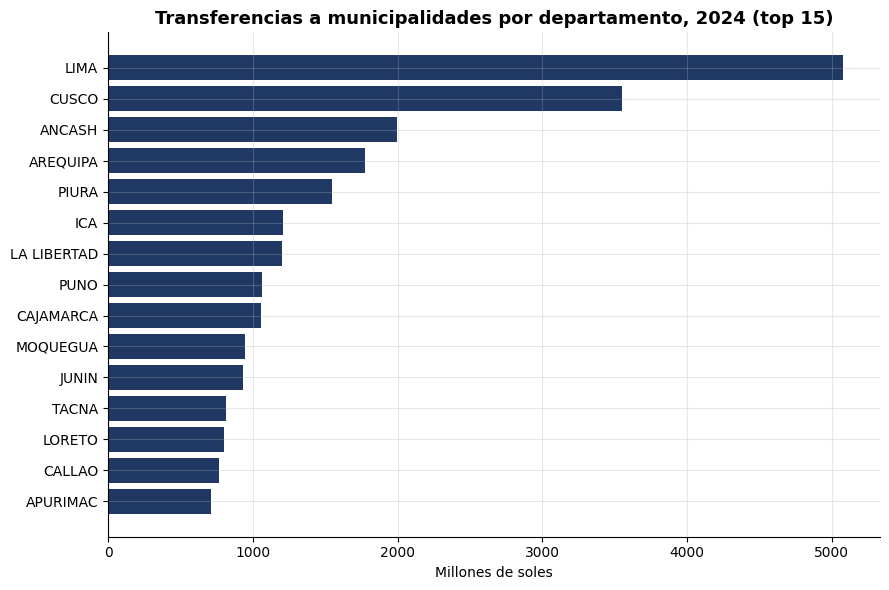

Lectura: la concentracion refleja poblacion y tambien rubros como el canon.
No permite concluir nada sobre eficiencia ni sobre equidad del reparto.


In [29]:
# GRAFICO 1: Total por departamento
col_dep = "departamento" if "departamento" in base.columns else "DEPARTAMENTO_MEF"
por_dep = (base.groupby(col_dep)["MONTO_ACREDITADO"].sum()
               .sort_values(ascending=False).head(15) / 1e6)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(por_dep.index[::-1], por_dep.values[::-1], color=AZUL)
ax.set_title(f"Transferencias a municipalidades por departamento, {ANIO} (top 15)",
             fontsize=13, weight="bold")
ax.set_xlabel("Millones de soles")
plt.tight_layout(); plt.show()

print("Lectura: la concentracion refleja poblacion y tambien rubros como el canon.")
print("No permite concluir nada sobre eficiencia ni sobre equidad del reparto.")

[guardado: graficos/grafico_04.png]


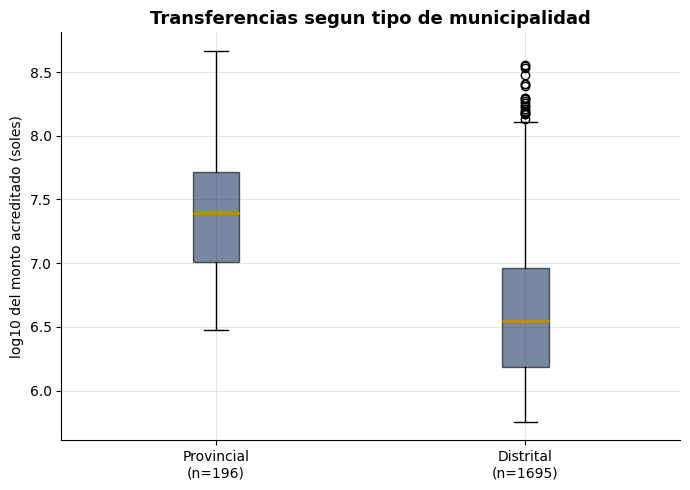

Lectura: compara nivel y dispersion entre ambos grupos. Una diferencia de
medianas es una asociacion descriptiva, no una explicacion.


In [31]:
#GRAFICO 2: Transferencias segun tipo de municipalidad
if col_tipo:
    etiq = {"1": "Provincial", "2": "Distrital"}
    grupos, nombres_g = [], []
    for k, v in etiq.items():
        s = base.loc[(base[col_tipo].astype(str).str.strip() == k) &
                     (base["MONTO_ACREDITADO"] > 0), "MONTO_ACREDITADO"].dropna()
        if len(s):
            grupos.append(np.log10(s)); nombres_g.append(f"{v}\n(n={len(s)})")

    if grupos:
        fig, ax = plt.subplots(figsize=(7, 5))
        bp = ax.boxplot(grupos, patch_artist=True)
        ax.set_xticklabels(nombres_g)
        for caja in bp["boxes"]:
            caja.set_facecolor(AZUL); caja.set_alpha(0.6)
        for med in bp["medians"]:
            med.set_color(ORO); med.set_linewidth(2)
        ax.set_ylabel("log10 del monto acreditado (soles)")
        ax.set_title("Transferencias segun tipo de municipalidad", fontsize=13, weight="bold")
        plt.tight_layout(); plt.show()
        print("Lectura: compara nivel y dispersion entre ambos grupos. Una diferencia de")
        print("medianas es una asociacion descriptiva, no una explicacion.")

[guardado: graficos/grafico_06.png]


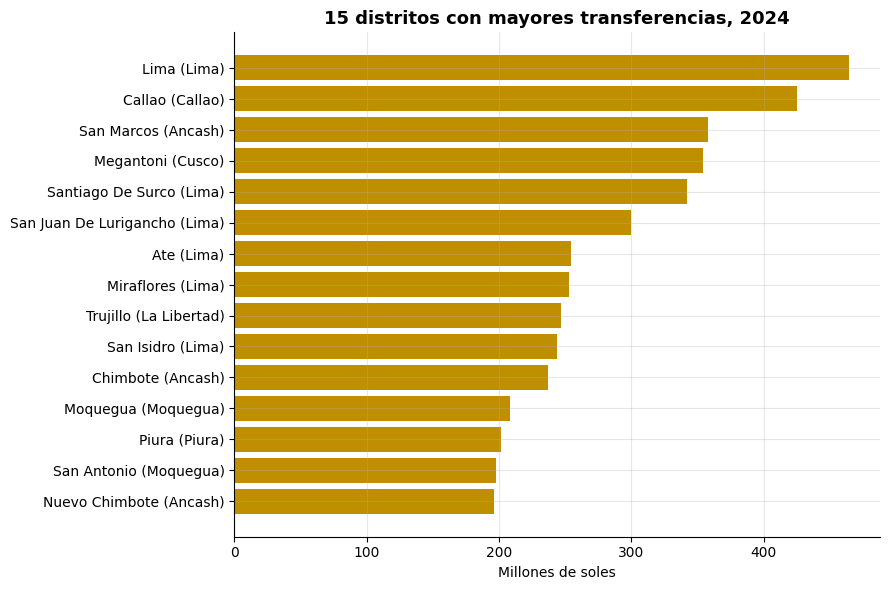

Lectura: identifica los casos extremos, que conviene revisar antes de calcular
cualquier promedio nacional porque distorsionan los agregados.


In [ ]:
#GRAFICO 3: Top 15 distritos
top = base.nlargest(15, "MONTO_ACREDITADO").iloc[::-1]

#Los nombres de distrito se repiten entre departamentos, asi que la etiqueta
#combina distrito y departamento (entre parentesis) para que cada barra sea unica.
if "distrito" in top.columns and "departamento" in top.columns:
    etiquetas = (top["distrito"].astype(str).str.title() + " (" +
                 top["departamento"].astype(str).str.title() + ")")
else:
    etiquetas = top["MUNICIPALIDAD"].astype(str).str.title()

pos = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(pos, top["MONTO_ACREDITADO"].to_numpy() / 1e6, color=ORO)
ax.set_yticks(pos); ax.set_yticklabels(etiquetas.tolist())
ax.set_xlabel("Millones de soles")
ax.set_title(f"15 distritos con mayores transferencias, {ANIO}", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

print("Lectura: identifica los casos extremos, que conviene revisar antes de calcular")
print("cualquier promedio nacional porque distorsionan los agregados.")

[guardado: graficos/grafico_05.png]


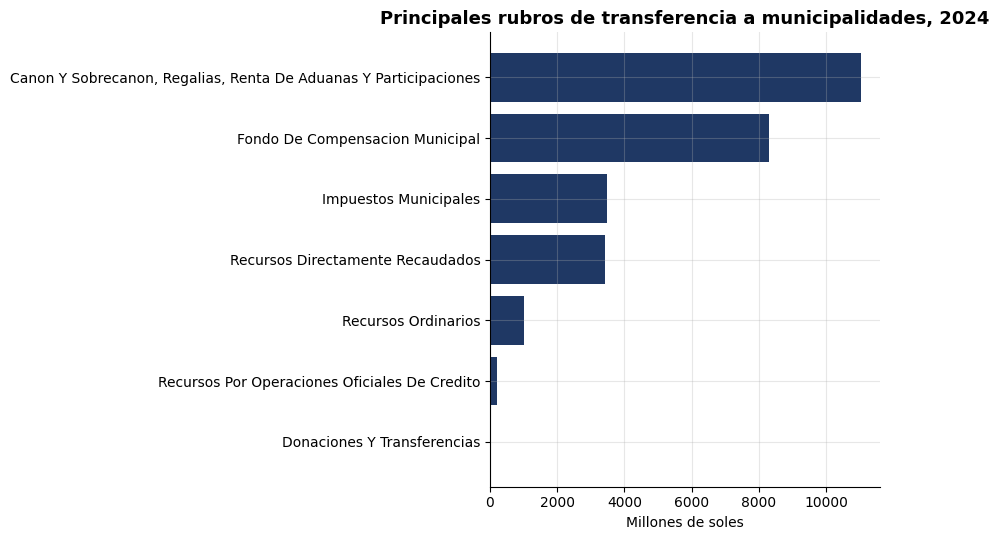

Lectura: muestra de donde viene el dinero que reciben las municipalidades.
Explica por que ciertos departamentos aparecen tan arriba en el grafico 3.


In [32]:
#GRAFICO 4: Composicion por rubro de transferencia
if por_rubro:
    rubros = (pd.concat(por_rubro, ignore_index=True)
                .groupby("RUBRO_NOMBRE", as_index=False)[MONTOS[-1]].sum()
                .sort_values(MONTOS[-1], ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(rubros["RUBRO_NOMBRE"].str.title()[::-1],
            (rubros[MONTOS[-1]] / 1e6)[::-1], color=AZUL)
    ax.set_xlabel("Millones de soles")
    ax.set_title(f"Principales rubros de transferencia a municipalidades, {ANIO}",
                 fontsize=13, weight="bold")
    plt.tight_layout(); plt.show()

    print("Lectura: muestra de donde viene el dinero que reciben las municipalidades.")
    print("Explica por que ciertos departamentos aparecen tan arriba en el grafico 3.")

## 10. Base integrada final y conclusiones preliminares

In [33]:
base_final = base.drop(columns=["_merge", "UBIGEO"], errors="ignore")
base_final.to_csv("base_integrada_hito1.csv", index=False, encoding="utf-8-sig")

print("Guardada como 'base_integrada_hito1.csv'")
print("Dimensiones:", base_final.shape)
print(f"\nUnidad de analisis: una municipalidad (un distrito), ejercicio {ANIO}")
base_final.head()

Guardada como 'base_integrada_hito1.csv'
Dimensiones: (1891, 10)

Unidad de analisis: una municipalidad (un distrito), ejercicio 2024


,ubigeo,departamento,provincia,distrito,tipomuni,MONTO_AUTORIZADO,MONTO_ACREDITADO,MUNICIPALIDAD,DEPARTAMENTO_MEF,ACREDITACION_PCT
0,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,20418557.60,20396056.85,MUNICIPALIDAD PROVINCIAL DE CHACHAPOYAS,AMAZONAS,99.889802
1,010102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,599031.30,599375.20,MUNICIPALIDAD DISTRITAL DE ASUNCION,AMAZONAS,100.057409
2,010103,AMAZONAS,CHACHAPOYAS,BALSAS,2,604515.32,604706.50,MUNICIPALIDAD DISTRITAL DE BALSAS,AMAZONAS,100.031625
3,010104,AMAZONAS,CHACHAPOYAS,CHETO,2,735512.76,735704.56,MUNICIPALIDAD DISTRITAL DE CHETO,AMAZONAS,100.026077
4,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,641171.34,641793.06,MUNICIPALIDAD DISTRITAL DE CHILIQUIN,AMAZONAS,100.096966


## 11. Matriz analitica — diccionario de variables de la base integrada

Documenta cada variable de `base_final`: de que fuente viene, que tipo de dato
es y que transformacion se le aplico. Sirve como trazabilidad de las decisiones
de limpieza e integracion, y como referencia rapida para redactar el informe.

In [36]:
#Diccionario base: fuente y descripcion de cada variable conocida.
#Si el nombre de alguna columna en tu base_final difiere, ajusta la clave aqui;
#lo que no este en el diccionario cae en "Por confirmar" sin romper la celda.
_descripciones = {
    "ubigeo":                  ("RENAMU (clave)", "Identificador geografico de 6 digitos, clave de integracion"),
    "departamento":             ("RENAMU",         "Departamento de la municipalidad"),
    "provincia":                ("RENAMU",         "Provincia de la municipalidad"),
    "distrito":                 ("RENAMU",         "Distrito de la municipalidad"),
    "tipomuni":                 ("RENAMU",         "Tipo de municipalidad (1=Provincial, 2=Distrital)"),
    "MUNICIPALIDAD":            ("MEF",            "Nombre de la unidad ejecutora / municipalidad"),
    "DEPARTAMENTO_MEF":         ("MEF",            "Departamento segun la unidad ejecutora del MEF"),
    "MONTO_AUTORIZADO":         ("MEF",            "Monto autorizado para transferencia, agregado a nivel distrito, ejercicio 2024"),
    "MONTO_ACREDITADO":         ("MEF",            "Monto efectivamente acreditado, agregado a nivel distrito, ejercicio 2024"),
    "ACREDITACION_PCT":         ("Derivada",       "Monto acreditado como % del autorizado = 100 * MONTO_ACREDITADO / MONTO_AUTORIZADO"),
}

def _transformacion(col, fuente):
    if fuente == "Derivada":
        return "Calculada en el cuaderno a partir de otras columnas (Seccion 7, Decision 4)"
    if fuente == "MEF" and col in ("MONTO_AUTORIZADO", "MONTO_ACREDITADO"):
        return "Agregada por suma a nivel distrito (groupby UBIGEO), desde el detalle original"
    if fuente == "RENAMU (clave)":
        return "Normalizada a texto, 6 digitos con ceros a la izquierda (Seccion 6)"
    return "Tomada tal cual de la fuente, sin transformar"

filas = []
for col in base_final.columns:
    fuente, desc = _descripciones.get(col, ("Por confirmar", "Agregar descripcion"))
    filas.append({
        "variable": col,
        "fuente": fuente,
        "tipo_dato": str(base_final[col].dtype),
        "descripcion": desc,
        "transformacion": _transformacion(col, fuente),
    })

matriz_analitica = pd.DataFrame(filas)
matriz_analitica.to_csv("matriz_analitica_hito1.csv", index=False, encoding="utf-8-sig")

print(f"Matriz analitica: {len(matriz_analitica)} variables.")
print(f"Unidad de analisis: una municipalidad (un distrito), ejercicio {ANIO}.")
print("Guardada como 'matriz_analitica_hito1.csv'")
matriz_analitica

Matriz analitica: 10 variables.
Unidad de analisis: una municipalidad (un distrito), ejercicio 2024.
Guardada como 'matriz_analitica_hito1.csv'


,variable,fuente,tipo_dato,descripcion,transformacion
0,ubigeo,RENAMU (clave),object,"Identificador geografico de 6 digitos, clave d...","Normalizada a texto, 6 digitos con ceros a la ..."
1,departamento,RENAMU,object,Departamento de la municipalidad,"Tomada tal cual de la fuente, sin transformar"
2,provincia,RENAMU,object,Provincia de la municipalidad,"Tomada tal cual de la fuente, sin transformar"
3,distrito,RENAMU,object,Distrito de la municipalidad,"Tomada tal cual de la fuente, sin transformar"
4,tipomuni,RENAMU,object,"Tipo de municipalidad (1=Provincial, 2=Distrital)","Tomada tal cual de la fuente, sin transformar"
5,MONTO_AUTORIZADO,MEF,float64,"Monto autorizado para transferencia, agregado ...",Agregada por suma a nivel distrito (groupby UB...
6,MONTO_ACREDITADO,MEF,float64,"Monto efectivamente acreditado, agregado a niv...",Agregada por suma a nivel distrito (groupby UB...
7,MUNICIPALIDAD,MEF,object,Nombre de la unidad ejecutora / municipalidad,"Tomada tal cual de la fuente, sin transformar"
8,DEPARTAMENTO_MEF,MEF,object,Departamento segun la unidad ejecutora del MEF,"Tomada tal cual de la fuente, sin transformar"
9,ACREDITACION_PCT,Derivada,float64,Monto acreditado como % del autorizado = 100 *...,Calculada en el cuaderno a partir de otras col...


### Conclusiones preliminares

1. **Cobertura del cruce.** De los 1,891 distritos del marco RENAMU cruzaron 1,891 (100%).
2. **Concentracion.** La mediana de transferencias fue S/,4,340,954 y el promedio S/.14,548,107.
   El indice de Gini fue 0.721, lo que indica un alto nivel de desigualdad en la distribución de las transferencias.  La mitad de los distritos que menos recibe concentra apenas el 6.6% del total nacional. El indicador mide la desigualdad del reparto de forma descriptiva y no permite determinar si la distribución es justa o injusta; parte de las diferencias puede responder a factores como la población y la asignación de rubros específicos, entre ellos el canon.
3. **Composicion.** Los rubros que más pesan son Canon y sobrecanon, regalías, renta de aduanas y participaciones (S/ 11,052 millones) y el Fondo de Compensación Municipal (S/ 8,300 millones). Les siguen Impuestos Municipales (S/ 3,469 millones) y Recursos Directamente Recaudados (S/ 3,414 millones). Esta composición ayuda a contextualizar por qué Lima (S/ 5,080 millones), Cusco (S/ 3,553 millones) y Áncash (S/ 1,993 millones) encabezan el ranking departamental.
